# 4.4.3 有限时间增长率与算术精度

## 学习目标与先修知识

能推导切向扰动的有限时间对数增长率，处理零导数（derivative），比较 float 与 Decimal 轨迹（trajectory），并把有限证据与长期混沌（chaos）性质分开。

先修：上一节的局部扰动倍率与对数；循环和 Python 数值类型。 [复习上一节](02-邻近轨迹与预测期限.ipynb)。

## 具体问题

一条后段不规则轨迹，加上一个正的增长率，足以宣称所有初值（initial condition）都混沌吗？先明确被计算的量，再主动寻找会让结论失效的边界。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
r,x=2.5,.6
print('不动点处局部倍率',r*(1-2*x),'自然对数',math.log(abs(r*(1-2*x))))
print('r=4,x=0.5 时导数为',4*(1-2*.5),'，log(0) 不可作为有限实数返回。')

不动点处局部倍率 -0.4999999999999999 自然对数 -0.6931471805599455
r=4,x=0.5 时导数为 0.0 ，log(0) 不可作为有限实数返回。


## 模型假设

采用 logistic 映射（logistic map）。增长率先烧去 burn 次迭代，再对接下来的 N 个当前状态（state）计算 log|r(1−2x)|。遇到零导数时数学上产生负无穷，本节计算函数返回 None 并说明原因，不加任意小常数。

精度对照使用字符串定义 r='3.9'、x0='0.2'、y0='0.200000001'，分别用 float 和 Decimal 的 40 位有效数字推进 35 代。两种计算都按各自精度舍入；较高精度提供一组算术误差更小的对照。

## 数学解释与推导

多步切向扰动近似相乘：δ_N≈δ_0∏_(n=0)^(N−1)F′(x_n)。取绝对值、自然对数（natural logarithm）并除以 N，得到
$$\lambda_N=\frac1N\sum_{n=0}^{N-1}\log|F'(x_n)|.$$
这个**有限时间 Lyapunov 指数（finite-time Lyapunov exponent）**沿一条指定轨迹及窗口计算；在相应极限（limit）存在等条件下，N→∞ 的量才对应长期指数。计算中烧去暂态（transient）、改变窗口长度、换初值和提高精度，各检查不同问题。

若某项导数恰为零，切向乘积为零，对数和含 −∞。返回 None 是为可读与可保存的有限数值接口保留特殊状态，不是把结果定义成零。真实有限扰动还可能由高阶项决定；切向零值与“所有有限误差都消失”不是同一个声明。

正 λ_N 表示当前窗口内的平均切向扩张。混沌涉及长期非周期运动及敏感性等性质，因此还要比较不同初值和窗口，并留意下面的特殊轨道。

例如 r=4、x0=1/2 精确产生 1/2→1→0→0，这是特殊轨道。又如不同十进制初值可在 float 中合并。确定性不保证长期逐步预测，算术差异也不自动意味着模型（model）包含随机机制。

Decimal 应直接从字符串构造，而非先转成 float 再补位。通过 localcontext 固定有效数字数和默认的半偶舍入，记录运算次序。增大精度可延长数值参照窗口，却不会减少真实模型或测量误差。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def logistic_path(r,initial,steps):
    values=[initial]
    for _ in range(steps):values.append(r*values[-1]*(1-values[-1]))
    return values

def finite_growth(r,initial,burn,steps):
    state=initial
    for _ in range(burn):state=r*state*(1-state)
    logs=[]
    for _ in range(steps):
        derivative=abs(r*(1-2*state))
        if derivative==0:return None
        logs.append(math.log(derivative))
        state=r*state*(1-state)
    return sum(logs)/steps

def precision_separation(r_text,first_text,second_text,steps,precision,threshold):
    from decimal import Decimal,localcontext
    x,y=float(first_text),float(second_text)
    binary=[abs(x-y)]
    for _ in range(steps):
        x=float(r_text)*x*(1-x);y=float(r_text)*y*(1-y)
        binary.append(abs(x-y))
    with localcontext() as context:
        context.prec=precision
        r=Decimal(r_text);a=Decimal(first_text);b=Decimal(second_text)
        decimal=[float(abs(a-b))]
        for _ in range(steps):
            a=r*a*(1-a);b=r*b*(1-b)
            decimal.append(float(abs(a-b)))
    first=lambda values:next((i for i,d in enumerate(values) if d>threshold),None)
    return binary,decimal,first(binary),first(decimal)

## 对照实验

| r | 窗口 N | 有限对数增长率 /代 |
| --- | --- | --- |
| 2.5 | 100 | -0.693147 |
| 2.5 | 500 | -0.693147 |
| 2.5 | 1500 | -0.693147 |
| 3.2 | 100 | -0.916291 |
| 3.2 | 500 | -0.916291 |
| 3.2 | 1500 | -0.916291 |
| 3.9 | 100 | 0.479744 |
| 3.9 | 500 | 0.460761 |
| 3.9 | 1500 | 0.478222 |

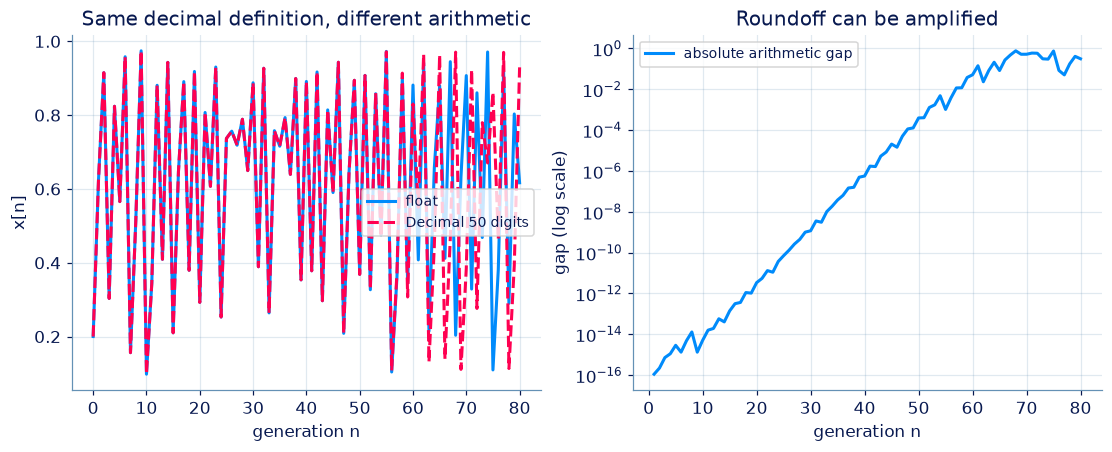

零差未画在对数轴；50 位结果仍是数值参照。


In [4]:
rows=[]
for r in [2.5,3.2,3.9]:
    for window in [100,500,1500]:rows.append((r,window,finite_growth(r,.2,300,window)))
display(Markdown(show_table(['r','窗口 N','有限对数增长率 /代'],rows)))
from decimal import Decimal,localcontext
float_states=logistic_path(3.9,.2,80)
with localcontext() as ctx:
    ctx.prec=50
    r=Decimal('3.9');x=Decimal('0.2');high=[float(x)]
    for _ in range(80):x=r*x*(1-x);high.append(float(x))
gap=np.abs(np.array(float_states)-high)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(float_states,color=BLUE,label='float')
axes[0].plot(high,color=PINK,ls='--',label='Decimal 50 digits')
positive=gap>0
axes[1].semilogy(np.flatnonzero(positive),gap[positive],color=BLUE,label='absolute arithmetic gap')
axes[0].set(xlabel='generation n',ylabel='x[n]',title='Same decimal definition, different arithmetic')
axes[1].set(xlabel='generation n',ylabel='gap (log scale)',title='Roundoff can be amplified')
for ax in axes:ax.legend(fontsize=9)
plt.show()
print('零差未画在对数轴；50 位结果仍是数值参照。')

## 结果解释

表格把参数（parameter）和窗口分别列出，读者能看到周期吸引与复杂例子的增长率差异，也能检查窗口依赖。图中两条算法没有随机输入（input），却可能在后段分离。

这并不推翻短期有效预测，也不证明真实系统一定混沌。进入下一篇的随机性之前，先保留这条边界：不规则可以来自确定性机制，随机性需要自己的建模假设和检验。

### 独立核对

用可精确表示的短轨道和不动点（fixed point）对数值核对实现；避免拿另一条混沌长轨迹的逐点一致性作为唯一准确性判据。

In [5]:
assert abs(finite_growth(2.5,.6,0,50)-math.log(.5))<1e-12
assert finite_growth(4,.5,0,10) is None
assert logistic_path(4,.5,4)==[.5,1.,0.,0.,0.]
binary,decimal,first_a,first_b=precision_separation('2','.25','.5',2,30,.2)
assert binary==decimal==[.25,.125,.03125] and first_a==first_b==0
print('不动点指数、零导数、特殊轨道和精度接口通过。')

不动点指数、零导数、特殊轨道和精度接口通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-04-混沌与可预测范围/explore/)：先预测条件变化的后果，再用交互对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算指定窗口的切向增长率

先丢弃 burn 次迭代，再对 logistic 映射（logistic map）计算 steps 个局部导数（derivative）的自然对数（natural logarithm）均值。遇到零导数时返回 None，表示该有限和包含 log(0)，不能擅自加一个小数规避。

**函数与代码模板**

```python
def solve(
    r: float,
    initial: float,
    burn: int,
    steps: int,
) -> float | None:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `r` | `float` | 共同参数（parameter）。 | 1 |
| `initial` | `float` | 最初状态（state）。 | 1 |
| `burn` | `int` | 先丢弃的更新次数。 | 1 |
| `steps` | `int` | 取对数项数。 | 1 |

**返回值**

直接返回 growth（float | None）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `growth` | <code>float &#124; None</code> | 有限窗口均值；任何导数为零时 None。 | 每代 |

**计算规则**

烧去 burn 步后，以当前 x 计算 log(abs(r*(1−2*x)))，再更新 x；重复 steps 次并平均。使用自然对数。 为固定浮点实验，使用 Python float；每次更新按 (r*x)*(1-x) 的括号次序，不改写成 r*(x-x*x)。长轨迹（trajectory）的舍入差异会被放大。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- 0≤r≤4；0≤initial≤1；0≤burn≤1000；1≤steps≤2000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| r | 共同参数（parameter）。 | 2.5 | 1 |
| initial | 最初状态（state）。 | 0.6 | 1 |
| burn | 先丢弃的更新次数。 | 0 | 1 |
| steps | 取对数项数。 | 3 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
r = 2.5
initial = 0.6
burn = 0
steps = 3

result = solve(r, initial, burn, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| growth | 有限窗口均值；任何导数为零时 None。 | ≈ -0.6931472 | 每代 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = -0.6931471805599451
```

**样例解释**

r=2.5、x=0.6 为不动点（fixed point），导数绝对值为 0.5，每项都是 log(0.5)，均值约 −0.693147。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算指定窗口的切向增长率](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-finite-growth)

### 第 2 题 · 单项选择题：有限时间正值能证明什么

某条轨迹（trajectory）一个短窗口的对数导数（derivative）均值为正。哪项正确？

- **A.** 所有初值（initial condition）的长期指数完全相同。
- **B.** 任意观测（observation）误差都永远指数增长。
- **C.** 已经证明整个参数（parameter）区间都混沌（chaos）。
- **D.** 它是该轨迹该窗口的切向扩张证据，仍需检查窗口、暂态（transient）、轨道和数值精度。

[作答：有限时间正值能证明什么](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-finite-positive)

### 第 3 题 · 单项选择题：怎样处理零导数

局部导数（derivative）恰为零。对对数增长率的处理哪项正确？

- **A.** 强行返回 0，表示不变。
- **B.** 换成 10⁻⁸ 且不说明。
- **C.** 数学上对数为负无穷；计算契约可返回明确的缺失标记，并解释原因。
- **D.** 把这一项删除，平均分母保持原样。

[作答：怎样处理零导数](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-log-zero)

### 第 4 题 · 单项选择题：特殊初值为何推翻不了典型行为

r=4，初值（initial condition） x0=0.5 给出 0.5→1→0→0。哪项正确？

- **A.** r=4 的每条轨迹（trajectory）都如此。
- **B.** 存在特殊轨道；不能把它外推为所有初值，也不能把所有初值强称为混沌（chaos）。
- **C.** 计算必须加噪声来阻止这条轨道。
- **D.** 数学确定性排除了复杂长期行为。

[作答：特殊初值为何推翻不了典型行为](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-exact-special-orbit)

### 第 5 题 · 单项选择题：增加算术精度意味着什么

两个精度版本在早期一致、后期分离。哪项解读合适？

- **A.** 舍入误差（round-off error）会被动力学放大；更高精度提供更长参考窗口，但仍需模型（model）与初值（initial condition）误差分析。
- **B.** 舍入本质上就是随机过程。
- **C.** 只选与预期图像最像的版本即可。
- **D.** 精度较高的版本一定等于真实生理系统。

[作答：增加算术精度意味着什么](http://127.0.0.1:8000/chapters/04-04-%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%8F%AF%E9%A2%84%E6%B5%8B%E8%8C%83%E5%9B%B4/practice/?question=p04-digits-vs-certainty)